In [1]:
import pandas as pd
from pathlib import Path

folder = Path(r"C:\Users\prith\Restaurant-Data-Analysis\data")

# Automatically find the CSV, regardless of extra spaces
csv_files = list(folder.glob("*.csv"))

if not csv_files:
    print("No CSV file found in the data folder.")
else:
    csv_path = csv_files[0]
    df = pd.read_csv(csv_path)

    print("Dataset loaded successfully!")
    print("Shape:", df.shape)

    display(df.head())

Dataset loaded successfully!
Shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [2]:

# Step 1: Inspect the dataset

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget variable summary:")
print(df["Aggregate rating"].describe())

Dataset shape: (9551, 21)

Column names:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']

Missing values in each column:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

Duplicate rows: 0

Target 

In [3]:

# Step 2: Create a clean copy of the dataset

df_clean = df.copy(deep=True)

# Fill missing cuisine values
df_clean["Cuisines"] = df_clean["Cuisines"].fillna("Unknown")

# Remove extra spaces from text columns
text_columns = df_clean.select_dtypes(include=["object", "str"]).columns

for column in text_columns:
    df_clean[column] = df_clean[column].str.strip()

# Check the results
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

Original shape: (9551, 21)
Cleaned shape: (9551, 21)
Missing values: 0
Duplicate rows: 0


In [4]:

# Step 3: Investigate zero ratings

zero_rating = df_clean[df_clean["Aggregate rating"] == 0]

print("Number of zero-rated restaurants:", len(zero_rating))

print("\nRating text for zero-rated restaurants:")
print(zero_rating["Rating text"].value_counts())

print("\nAll rating categories:")
print(df_clean["Rating text"].value_counts())

Number of zero-rated restaurants: 2148

Rating text for zero-rated restaurants:
Rating text
Not rated    2148
Name: count, dtype: int64

All rating categories:
Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64


In [5]:

# Step 4: Keep only restaurants with actual ratings

model_df = df_clean[
    df_clean["Aggregate rating"] > 0
].copy()

# Check the new dataset
print("Original dataset size:", len(df_clean))
print("Unrated restaurants removed:", 
      (df_clean["Aggregate rating"] == 0).sum())

print("Dataset size for modeling:", len(model_df))

print("\nRating summary after filtering:")
print(model_df["Aggregate rating"].describe())

Original dataset size: 9551
Unrated restaurants removed: 2148
Dataset size for modeling: 7403

Rating summary after filtering:
count    7403.000000
mean        3.440024
std         0.552195
min         1.800000
25%         3.000000
50%         3.400000
75%         3.800000
max         4.900000
Name: Aggregate rating, dtype: float64


In [6]:

# Step 5: Select input features and target

features = [
    "Country Code",
    "City",
    "Longitude",
    "Latitude",
    "Cuisines",
    "Average Cost for two",
    "Currency",
    "Has Table booking",
    "Has Online delivery",
    "Is delivering now",
    "Price range",
    "Votes"
]

X = model_df[features]
y = model_df["Aggregate rating"]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

print("\nSelected features:")
print(X.columns.tolist())

print("\nTarget preview:")
print(y.head())

Feature data shape: (7403, 12)
Target data shape: (7403,)

Selected features:
['Country Code', 'City', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Price range', 'Votes']

Target preview:
0    4.8
1    4.5
2    4.4
3    4.9
4    4.8
Name: Aggregate rating, dtype: float64


In [7]:

# Step 6: Identify numerical and categorical features

numeric_features = [
    "Country Code",
    "Longitude",
    "Latitude",
    "Average Cost for two",
    "Price range",
    "Votes"
]

categorical_features = [
    "City",
    "Cuisines",
    "Currency",
    "Has Table booking",
    "Has Online delivery",
    "Is delivering now"
]

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 6
Categorical features: 6


In [8]:

from sklearn.model_selection import train_test_split

X = X.copy()

# Treat country code as a category, not a continuous measurement
X["Country Code"] = X["Country Code"].astype(str)

numeric_features.remove("Country Code")
categorical_features.append("Country Code")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5922, 12)
Testing features: (1481, 12)
Training target: (5922,)
Testing target: (1481,)


In [9]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [10]:

# Process numerical columns
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Process categorical columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [11]:

from sklearn.ensemble import RandomForestRegressor

# Combine preprocessing and model into one pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=3
    ))
])

# Train using only the training data
model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [12]:

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Predict ratings for the test data
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R² Score:", round(r2, 3))

Model Evaluation Results
------------------------
MAE: 0.247
MSE: 0.112
RMSE: 0.334
R² Score: 0.639


In [13]:

# Get the trained preprocessing step
fitted_preprocessor = model.named_steps["preprocessor"]

# Get names of the encoded features
encoded_feature_names = fitted_preprocessor.get_feature_names_out()

# Get importance values from the trained Random Forest
importance_values = model.named_steps["regressor"].feature_importances_

# Create a table of feature importance
importance_df = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": importance_values
})

# Sort from highest to lowest
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display the 15 most important encoded features
importance_df.head(15)

,Feature,Importance
4,num__Votes,0.538514
0,num__Longitude,0.144215
1,num__Latitude,0.127043
2,num__Average Cost for two,0.059686
1617,cat__Country Code_1,0.023393
1603,cat__Currency_Indian Rupees(Rs.),0.020086
1211,"cat__Cuisines_North Indian, Chinese",0.006809
3,num__Price range,0.006608
1614,cat__Has Online delivery_Yes,0.005589
1613,cat__Has Online delivery_No,0.005163


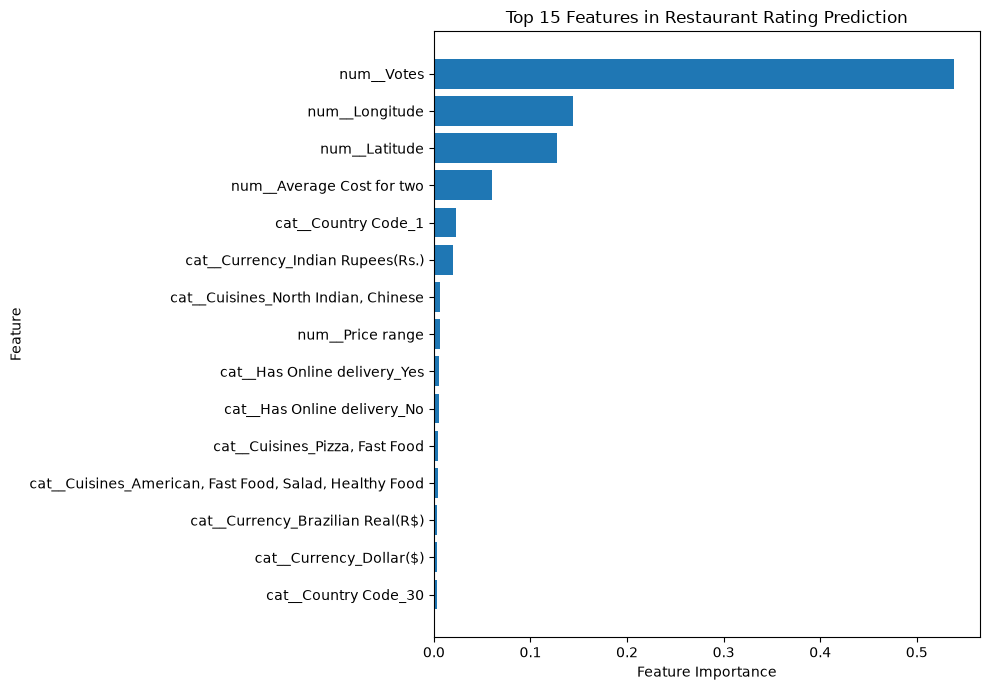

In [14]:

import matplotlib.pyplot as plt

# Select the 15 most important encoded features
top_features = importance_df.head(15).sort_values(
    by="Importance",
    ascending=True
)

# Create a horizontal bar chart
plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features in Restaurant Rating Prediction")
plt.tight_layout()
plt.show()


In [15]:

# Remove Votes from the input features
features_without_votes = [
    feature for feature in features
    if feature != "Votes"
]

X_no_votes = model_df[features_without_votes].copy()
X_no_votes["Country Code"] = X_no_votes["Country Code"].astype(str)

# Split using the same random seed
X_train_nv, X_test_nv, y_train_nv, y_test_nv = train_test_split(
    X_no_votes,
    y,
    test_size=0.2,
    random_state=42
)

# Create preprocessing for the reduced feature set
preprocessor_nv = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, [
            "Longitude",
            "Latitude",
            "Average Cost for two",
            "Price range"
        ]),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Build and train the second model
model_no_votes = Pipeline(steps=[
    ("preprocessor", preprocessor_nv),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=3
    ))
])

model_no_votes.fit(X_train_nv, y_train_nv)

print("Model without Votes trained successfully!")

Model without Votes trained successfully!


In [16]:

# Predict ratings using the model without Votes
y_pred_nv = model_no_votes.predict(X_test_nv)

# Calculate evaluation metrics
mae_nv = mean_absolute_error(y_test_nv, y_pred_nv)
mse_nv = mean_squared_error(y_test_nv, y_pred_nv)
rmse_nv = np.sqrt(mse_nv)
r2_nv = r2_score(y_test_nv, y_pred_nv)

print("Model WITHOUT Votes")
print("-------------------")
print("MAE:", round(mae_nv, 3))
print("MSE:", round(mse_nv, 3))
print("RMSE:", round(rmse_nv, 3))
print("R² Score:", round(r2_nv, 3))

Model WITHOUT Votes
-------------------
MAE: 0.297
MSE: 0.15
RMSE: 0.387
R² Score: 0.516


In [17]:

comparison_df = pd.DataFrame({
    "Model": ["With Votes", "Without Votes"],
    "MAE": [mae, mae_nv],
    "MSE": [mse, mse_nv],
    "RMSE": [rmse, rmse_nv],
    "R2 Score": [r2, r2_nv]
})

comparison_df.round(3)

,Model,MAE,MSE,RMSE,R2 Score
0,With Votes,0.247,0.112,0.334,0.639
1,Without Votes,0.297,0.150,0.387,0.516
